## Cargamos las Librerías:

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
import warnings
from typing import Optional
warnings.filterwarnings('ignore')
import pandas as pd
pd.set_option('display.float_format', '{:.2f}'.format)
import os
import sys

## Cargamos el Conjuntos de Datos:

In [3]:
homicidios = pl.read_csv('~/homicidios/data/final/homicidios_final.csv')
homicidios

ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,sem_gest,gramos,dia_ocurr,mes_ocurr,anio_ocur,dia_regis,mes_regis,anio_regis,dia_nacim,mes_nacim,anio_nacim,cond_act,ocupacion,escolarida,edo_civil,tipo_defun,ocurr_trab,lugar_ocur,par_agre,vio_fami,asist_medi,cirugia,natviole,necropsia,usonecrops,encefalica,donador,sitio_ocur,cond_cert,derechohab,embarazo,rel_emba,horas,minutos,capitulo,grupo,lista1,gr_lismex,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str
1,32,"""500 000 a 999 999 habitantes""","""Neumonía, no especificada""",null,"""Neumonía""","""Mujer""","""No""","""No""","""No""","""No aplica""","""Mexicana""","""Mexicana (no especificado de E…","""Setenta y tres años …","""No aplica""",null,18,12,2022,4,1,2023,8,"""Abril""",1949,"""Sí""","""Profesores y especialistas en …","""Profesional""","""Divorciado(a)""","""Enfermedad (Muerte natural)""","""No aplica para muerte natural …","""No aplica para muerte natural""","""No hubo violencia""","""No aplica cuando no es homicid…","""Con asistencia médica""","""No especificada""","""No""","""No""","""No aplica""","""No especificada""","""No aplica""","""ISSSTE""","""Otro médico""","""IMSS""","""No especificada ""","""No especificada""","""Veintiún horas""","""Cincuenta minutos""","""Otras enfermedades del sistema…","""Tumores (neoplasias) de compor…","""Neumonía""",null,"""Urbana""","""De 70 a 74 años""","""No especificada""","""Dieciocho días""","""Diciembre""",2022,null,null,"""Aguascalientes""","""Zacatecas"""
1,1,"""500 000 a 999 999 habitantes""","""Síndrome de dificultad respira…",null,"""Las demás enfermedades del apa…","""Mujer""","""No""","""No""","""No""","""No aplica""","""Mexicana""","""Mexicana (no especificado de E…","""Setenta y siete años …","""No aplica""",null,12,12,2022,4,1,2023,12,"""Julio""",1945,"""No""","""No trabaja""","""Sin escolaridad""","""Soltero(a)""","""Enfermedad (Muerte natural)""","""No aplica para muerte natural …","""No aplica para muerte natural""","""No hubo violencia""","""No aplica cuando no es homicid…","""Con asistencia médica""","""No especificada""","""No""","""No""","""No aplica""","""No""","""No aplica""","""Secretaría de salud""","""Médico tratante""","""Ninguna""","""No especificada ""","""No especificada""","""Cero horas""","""Cincuenta minutos""","""Otras enfermedades del sistema…","""Otros trastornos del ojo y sus…","""Resto de enfermedades del sist…",null,"""Urbana""","""De 75 a 79 años""","""No especificada""","""Doce días""","""Diciembre""",2022,null,null,"""Aguascalientes""","""Aguascalientes"""
1,1,"""500 000 a 999 999 habitantes""","""Enfermedad pulmonar obstructiv…",null,"""Enfermedades pulmonares obstru…","""Mujer""","""No""","""No""","""No""","""No aplica""","""Mexicana""","""Mexicana (no especificado de E…","""Sesenta y nueve años …","""No aplica""",null,17,12,2022,4,1,2023,24,"""Octubre""",1953,"""No""","""No trabaja""","""Primaria incompleta""","""Viudo(a)""","""Enfermedad (Muerte natural)""","""No aplica para muerte natural …","""No aplica para muerte natural""","""No hubo violencia""","""No aplica cuando no es homicid…","""Con asistencia médica""","""No especificada""","""No""","""No""","""No aplica""","""No""","""No aplica""","""Secretaría de salud""","""Otro médico""","""Ninguna""","""No especificada ""","""No especificada""","""Veinte horas""","""Quince minutos""","""Otras enfermedades del sistema…","""Trastorno mental no especific…","""Enfermedades crónicas de las …",null,"""Urbana""","""De 65 a 69 años""","""No especificada""","""Diecisiete días""","""Diciembre""",2022,null,null,"""Aguascalientes""","""Aguasc

In [12]:
homicidios['donador'].value_counts().rename({'count': 'Frecuencia'}).sort(by = 'Frecuencia', descending=True)

donador,Frecuencia
str,u32
"""No aplica""",787916
"""No""",9888
"""No especificada""",1593
"""Sí""",472


## Establecemos los Parámetros de los Gráficos:

In [4]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Enraizamos el Proyecto:

In [5]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

## Cargamos las Funciones Modulares:

In [6]:
import images.images
from images.images import graficar_homicidios_por_sitio
from images.images import graficar_homicidios_por_sitio_1
from images.images import graficar_homicidios_mujeres
from images.images import graficar_edad_fallecidos
from images.images import graficar_edad_fallecidos_sexo
from images.images import graficar_edad_nacim_sexo
from images.images import graficar_motivos_muerte

In [7]:
import settings.settings
from settings.settings import owid_palette
from settings.settings import gender_palette

## Homicidios en México por Sitio de Ocurrencia:

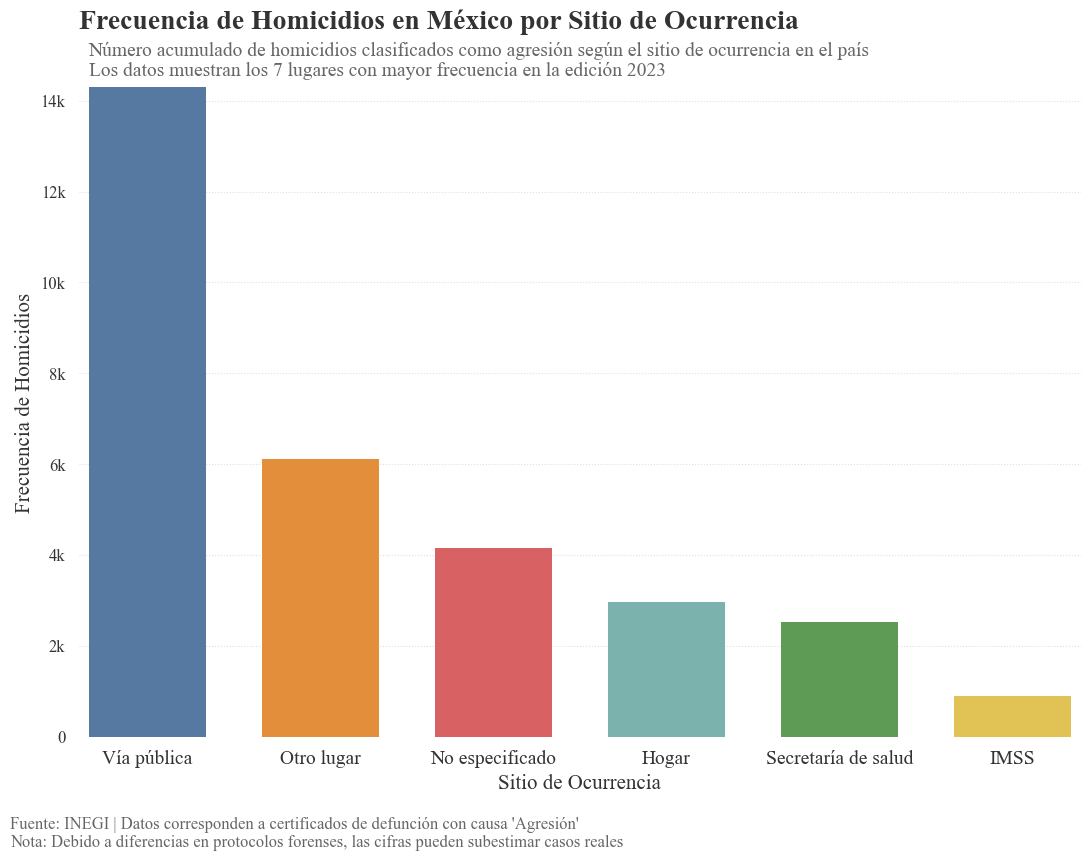

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Frecuencia de Homicidios en México por Sitio de Ocurrencia'}, xlabel='Sitio de Ocurrencia', ylabel='Frecuencia de Homicidios'>)

In [8]:
graficar_homicidios_por_sitio(homicidios, owid_palette)

## Homicidios en México por Sitio de Ocurrencia:

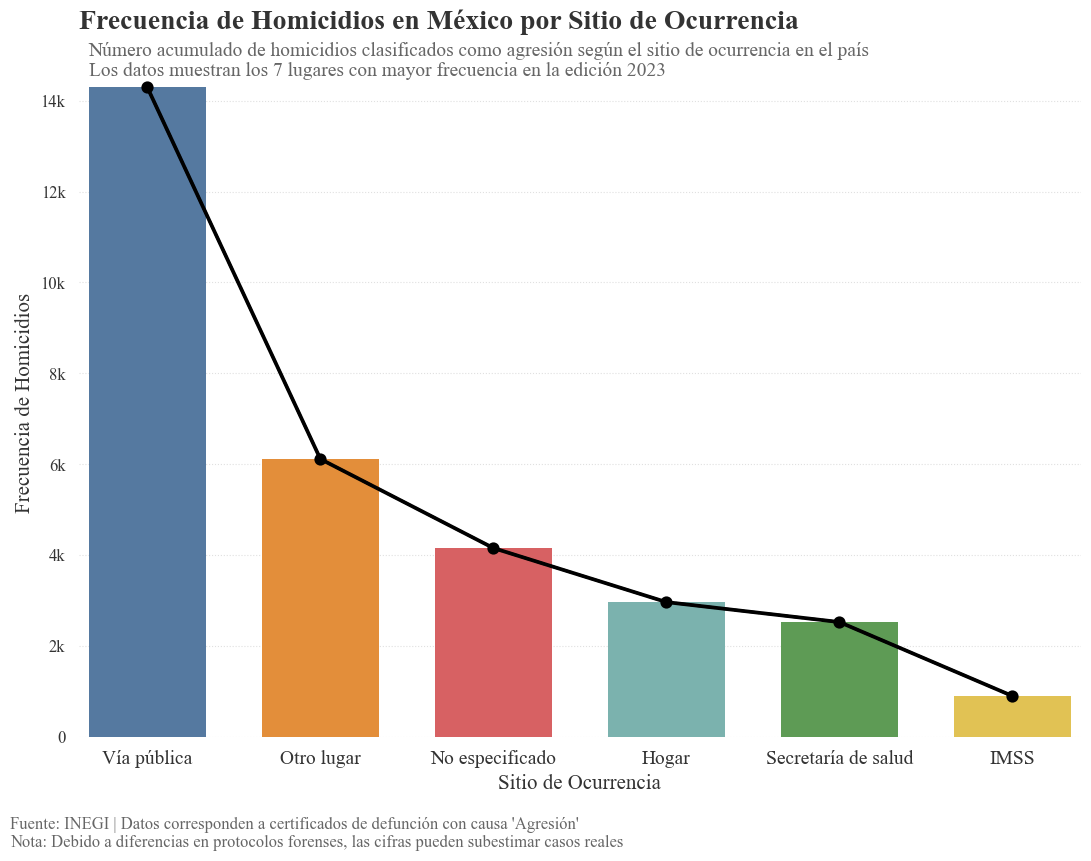

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Frecuencia de Homicidios en México por Sitio de Ocurrencia'}, xlabel='Sitio de Ocurrencia', ylabel='Frecuencia de Homicidios'>)

In [9]:
graficar_homicidios_por_sitio_1(homicidios, owid_palette)

## Homicidios de Mujeres en México por Sitio de Ocurrencia:

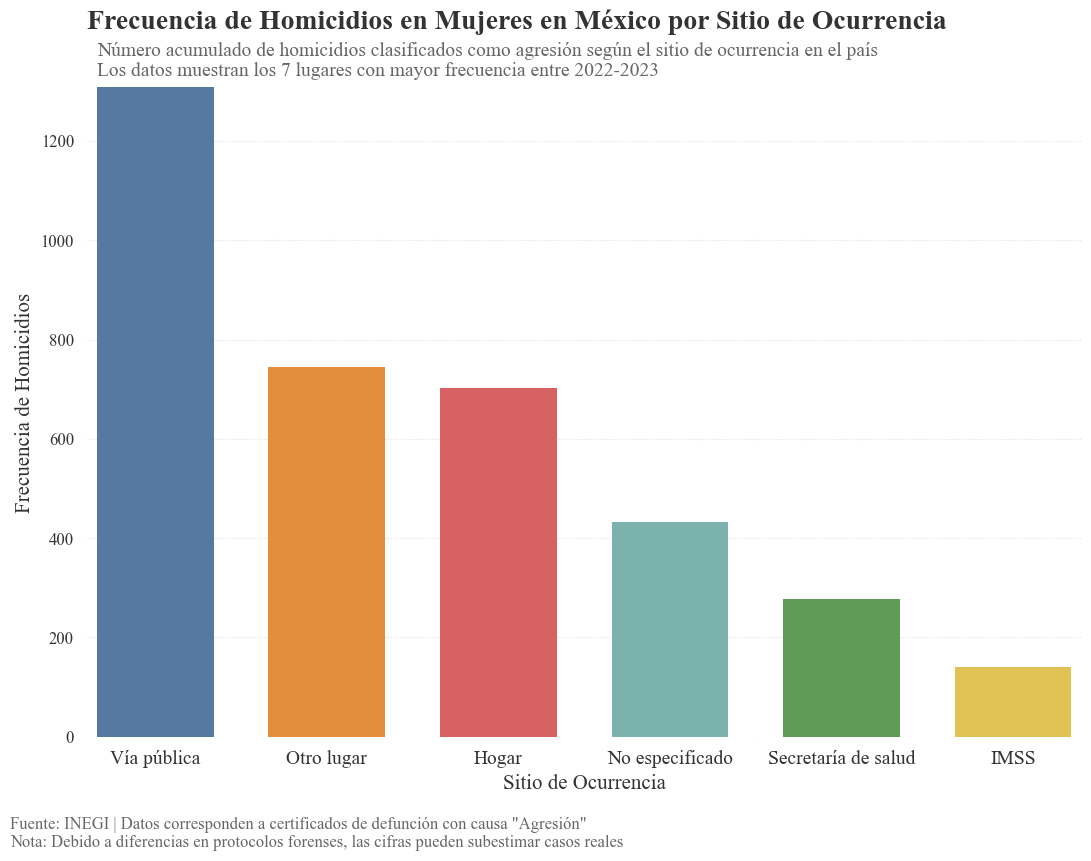

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Frecuencia de Homicidios en Mujeres en México por Sitio de Ocurrencia'}, xlabel='Sitio de Ocurrencia', ylabel='Frecuencia de Homicidios'>)

In [10]:
graficar_homicidios_mujeres(homicidios, owid_palette)

## Año de Nacimiento de las Personas Fallecidas en México:

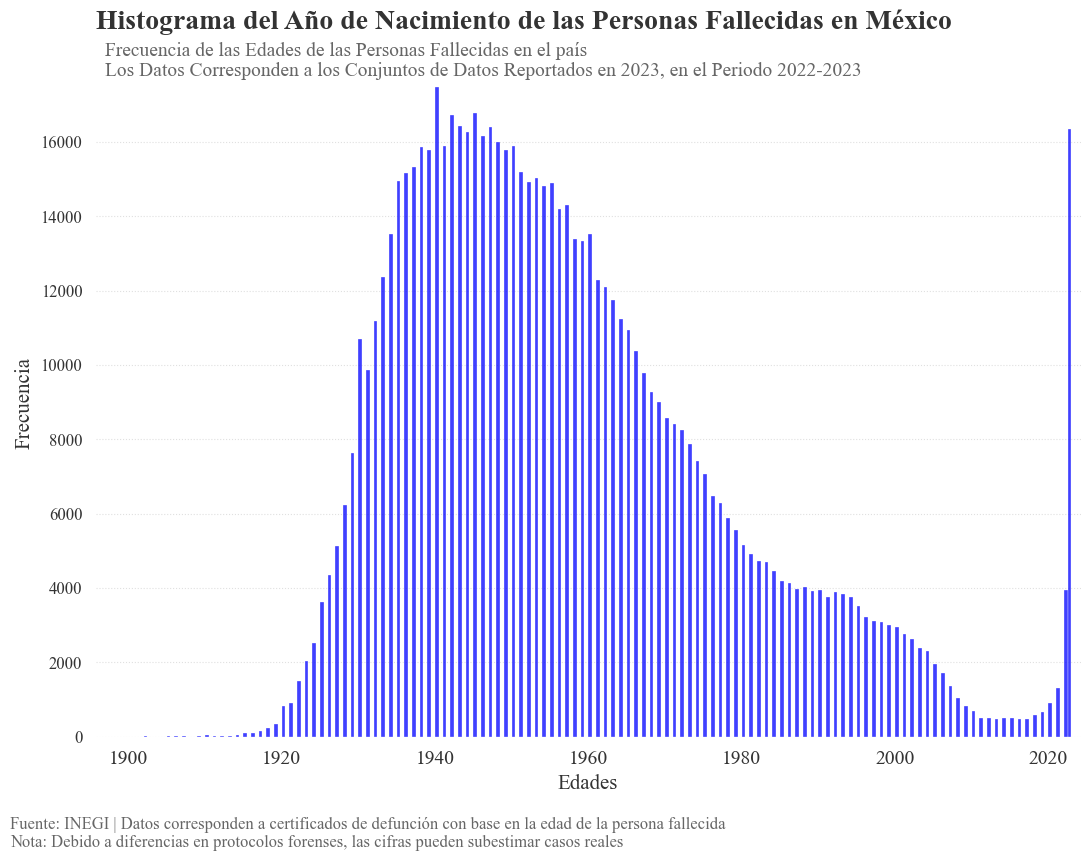

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Histograma del Año de Nacimiento de las Personas Fallecidas en México'}, xlabel='Edades', ylabel='Frecuencia'>)

In [11]:
graficar_edad_fallecidos(homicidios)

## Año de Nacimiento de las Personas Fallecidas en México Según el Sexo:

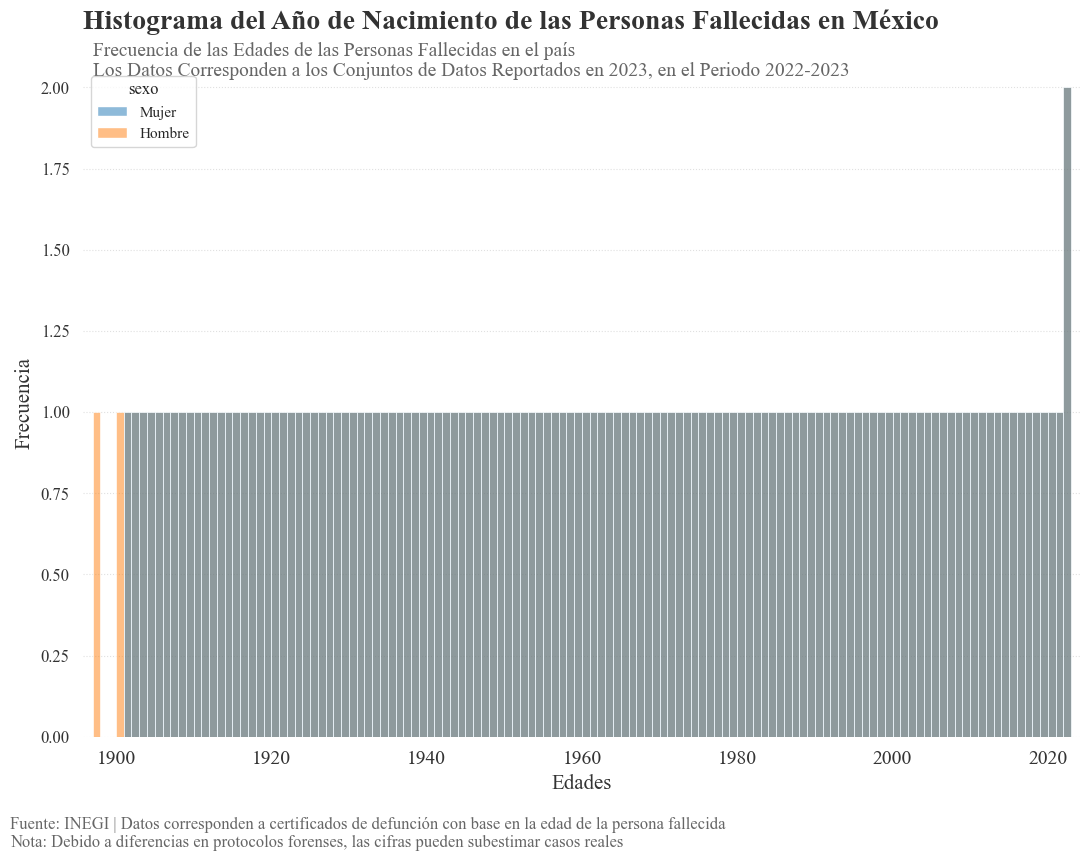

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Histograma del Año de Nacimiento de las Personas Fallecidas en México'}, xlabel='Edades', ylabel='Frecuencia'>)

In [12]:
graficar_edad_fallecidos_sexo(homicidios)

## Distribución de las Edades de las Personas Fallecidas en México:

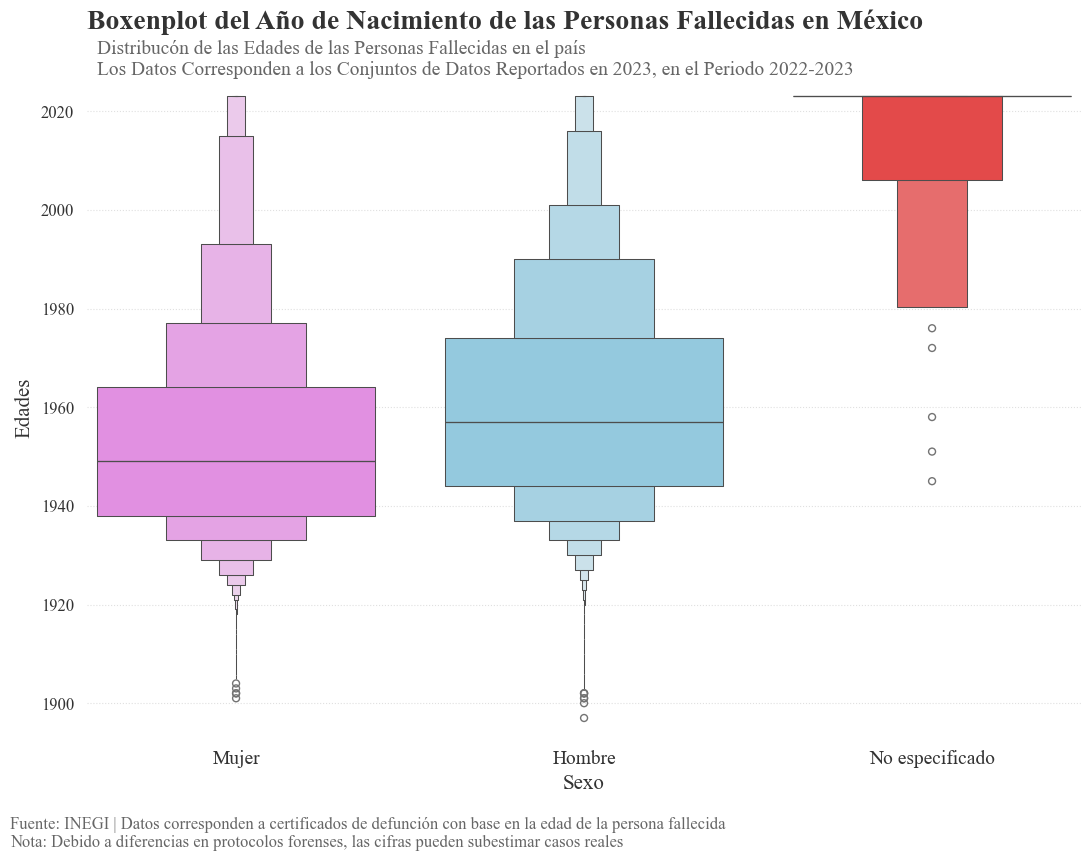

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Boxenplot del Año de Nacimiento de las Personas Fallecidas en México'}, xlabel='Sexo', ylabel='Edades'>)

In [13]:
graficar_edad_nacim_sexo(homicidios, gender_palette)

## Principales Motivos de Fallecimiento en México:

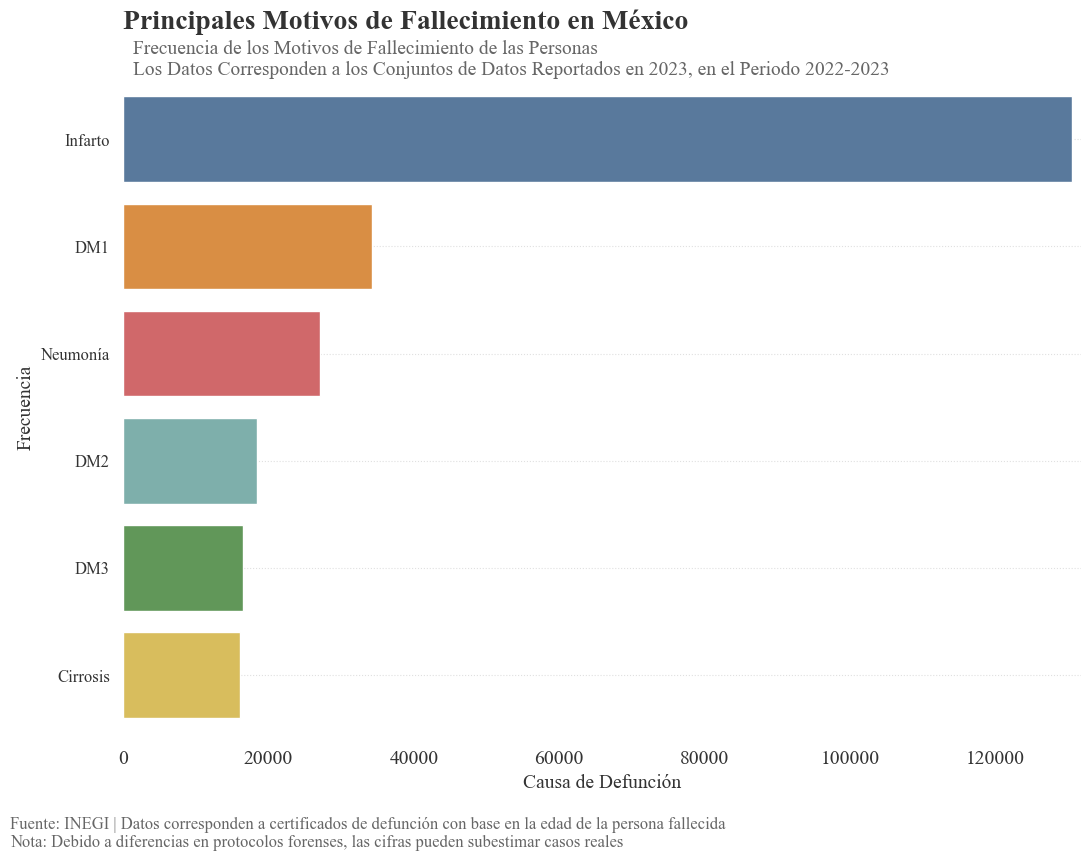

(<Figure size 1100x940 with 1 Axes>,
 <Axes: title={'left': 'Principales Motivos de Fallecimiento en México'}, xlabel='Causa de Defunción', ylabel='Frecuencia'>)

In [14]:
graficar_motivos_muerte(homicidios, owid_palette)